# Data Preprocessing:
Data preprocessing is the first step in any data analysis or machine learning pipeline. It involves cleaning, transforming and organizing raw data to ensure it is accurate, consistent and ready for modeling.

## Step by step implementation

### Step 1: Import Libraries and Load Dataset

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
df=pd.read_csv("../Data/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Step 2: Inspect Data and check missing values

In [3]:
df.info()
print("missing values:\n",df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB
missing values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement     

### Step 3:  Statistical Summary and Visualizing Outliers
Get numeric summaries like mean, median, min/max and detect unusual points (outliers). Outliers can skew models if not handled.

basic statistics:
               price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


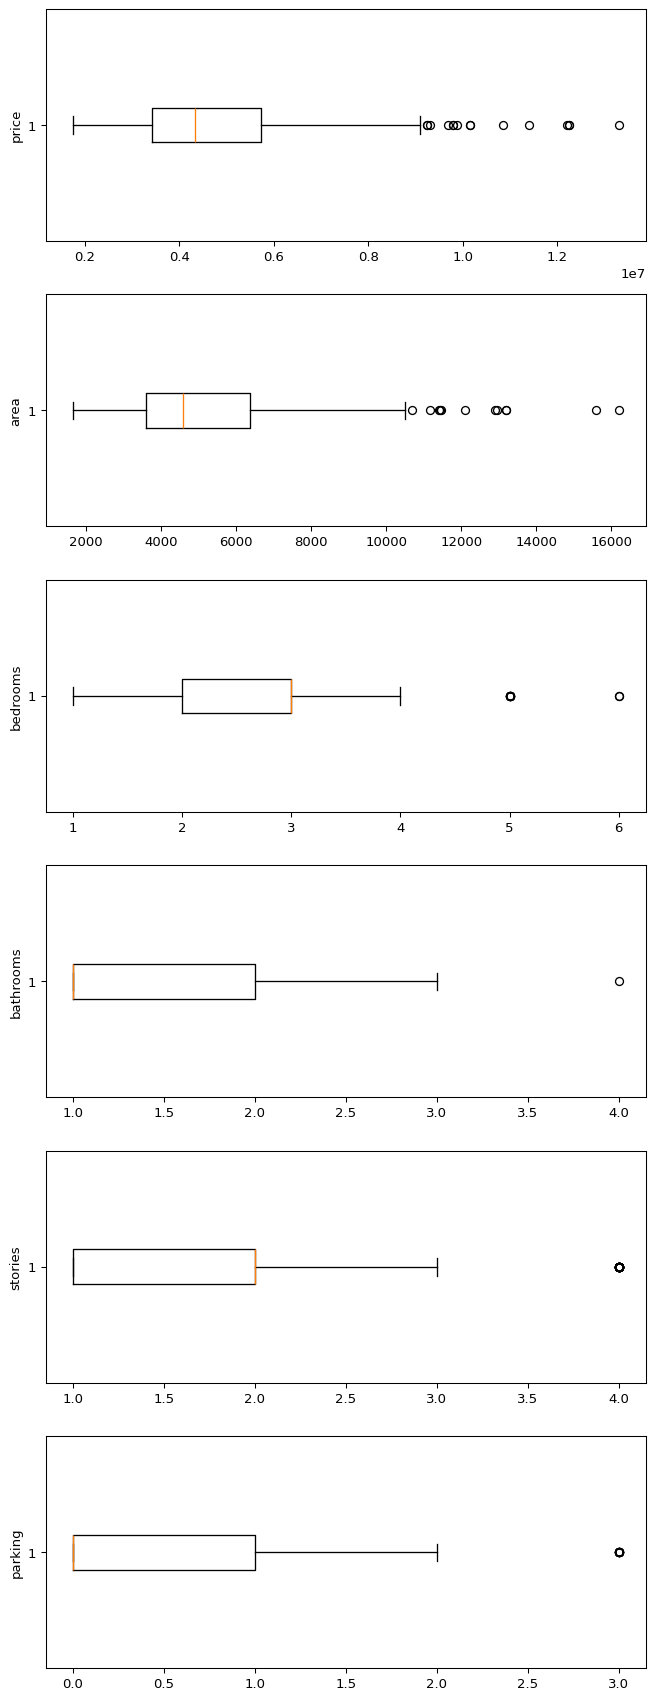

In [4]:
print("basic statistics:\n",df.describe())
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
fig, axs = plt.subplots(len(numeric_cols), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(numeric_cols):
    axs[i].boxplot(df[col].dropna(), vert=False)  
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()


### Step 4: Remove Outliers Using the Interquartile Range (IQR) Method

In [5]:
num_cols=["price","area","bedrooms","stories","parking"]
df_clean=df.copy()
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"\nOriginal rows: {len(df)}")
print(f"Rows after removing outliers: {len(df_clean)}")
print(f"Removed rows: {len(df) - len(df_clean)}")
                        


Original rows: 545
Rows after removing outliers: 463
Removed rows: 82


### Step 5: Correlation Analysis

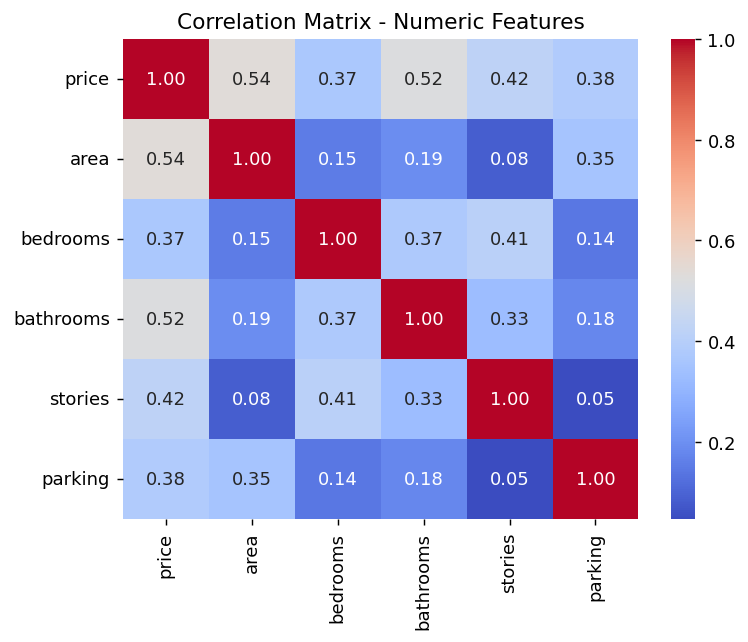

In [6]:
corr = df[numeric_cols].corr()

plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm")
plt.title('Correlation Matrix - Numeric Features')
plt.show()


### Step 6: Dropping unwanted columns

In [7]:
df=df_clean.drop(df_clean[["hotwaterheating","airconditioning","prefarea","basement","guestroom"]],axis=1)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,parking,furnishingstatus
15,9100000,6000,4,1,2,yes,2,semi-furnished
16,9100000,6600,4,2,2,yes,1,unfurnished
18,8890000,4600,3,2,2,yes,2,furnished
19,8855000,6420,3,2,2,yes,1,semi-furnished
20,8750000,4320,3,1,2,yes,2,semi-furnished


### Step 7: Extract cleaned CSV

In [8]:
df.to_csv("../Data/Housing_cleaned.csv", index=False)
print("Cleaned dataset saved to: ../Data/Housing_cleaned.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Cleaned dataset saved to: ../Data/Housing_cleaned.csv
Shape: (463, 8)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'parking', 'furnishingstatus']


### Step 8: Defining target and feature

In [9]:
X = df.drop(["price"], axis=1)
Y = df[["price"]]

print("Features (X) shape:", X.shape)
print("Features columns:", X.columns.tolist())
print("Target (Y) shape:", Y.shape)

Features (X) shape: (463, 7)
Features columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'parking', 'furnishingstatus']
Target (Y) shape: (463, 1)


## Data Preprocessing Complete

The data preprocessing phase for the Housing dataset has been successfully completed. The raw data has been cleaned, transformed, and saved for feature engineering and model building.

---

### Preprocessing Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Load Dataset | 545 records, 13 features loaded from Housing.csv |
| 2 | Data Inspection | No missing values found in any column |
| 3 | Outlier Detection | Box plots created for numeric columns |
| 4 | Outlier Removal | IQR method applied, 82 outliers removed |
| 5 | Correlation Analysis | Heatmap generated for numeric features |
| 6 | Feature Selection | 5 columns dropped (hotwaterheating, airconditioning, prefarea, basement, guestroom) |
| 7 | Save Cleaned Data | Housing_cleaned.csv saved with 463 records and 8 columns |

---

### Final Dataset Overview

- Total Records: 463
- Total Columns: 8 (7 features + 1 target)
- Target: price

### Features (X)

| Feature | Type | Description |
|---------|------|-------------|
| area | Numeric | Total area of the house in square feet |
| bedrooms | Numeric | Number of bedrooms |
| bathrooms | Numeric | Number of bathrooms |
| stories | Numeric | Number of floors |
| mainroad | Categorical | Access to main road (yes/no) |
| parking | Numeric | Number of parking spaces |
| furnishingstatus | Categorical | Furnishing status (furnished/semi-furnished/unfurnished) |

### Target Variable (Y)

| Variable | Type | Description |
|----------|------|-------------|
| price | Numeric | House price to be predicted |

---

### Saved Files

- Raw Data: ../Data/Housing.csv
- Cleaned Data: ../Data/Housing_cleaned.csv

---

### Next Phase: Feature Engineering

Feature engineering involves creating new features from existing data to improve model performance. The following steps are planned:

1. Encode categorical variables (Label Encoding / One-Hot Encoding)
2. Create new features (price per square foot, total rooms, etc.)
3. Apply feature scaling (StandardScaler / MinMaxScaler)
4. Feature selection based on correlation and importance
5. Prepare final dataset for modeling

---

### Key Insight

Area has the strongest correlation with price, followed by bathrooms and stories. This indicates that physical size and bathroom count are the most important predictors of house prices.

---

End of Data Preprocessing | Proceed to Feature Engineering Phase